# Notebook 7 — Prediction-Based Anomaly Detection

**Pipeline**
1. Load N-BEATS v2 predictions (best forecasting model, `avg_kwh` target) for each municipality.
2. Compute residuals: `residual = actual − predicted`.
3. Apply five anomaly detectors with contamination = 0.022 (from Ch. 3: ~2.2% of days show |z|>3 residuals):
   - Z-score threshold (|z| > 3) — interpretable baseline
   - Isolation Forest
   - Local Outlier Factor (LOF)
   - One-Class SVM
   - K-Means (k = 2) on residuals
4. Analyse temporal distribution: pre-COVID / in-COVID / post-COVID periods.
5. Cross-method agreement — ensemble vote (majority ≥ 3/5 methods).

**References (from literature review)**
- Zhang et al. [14]: prediction → K-Means on residual clusters
- Zangrando et al. [12]: IF, LOF, One-Class SVM outperform deep autoencoders
- Jesmeen et al. [8]: LOF + feature extraction performs consistently well
- Contamination prior 0.022 from thesis Section 3.5

In [1]:
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats

from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.svm import OneClassSVM
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})
sns.set_style('whitegrid')

BASE_PATH = Path(r'c:\Users\GONCA\Desktop\Iscte\MCD\Theses')
PRED_DIR  = BASE_PATH / 'forecasting_model_results_365_seasonality_v4_avg_kwh'
OUT_DIR   = BASE_PATH / 'anomaly_detection_results'
OUT_DIR.mkdir(exist_ok=True)

CONTAMINATION = 0.022   # from Ch. 3 Section 3.5
BEST_MODEL    = 'N-BEATS v2 (covariate-conditioned)'

MUNICIPALITIES = {
    'Vitoria-Gasteiz':      'Vitoria-Gasteiz_predictions.csv',
    'Donostia/San Sebastian': 'Donostia_San_Sebastian_predictions.csv',
    'Pamplona/Iruna':       'Pamplona_Iruna_predictions.csv',
}

# COVID period boundaries (daily granularity)
COVID_START = pd.Timestamp('2020-03-14')  # Spanish state of alarm
COVID_END   = pd.Timestamp('2021-05-09')  # end of state of alarm

def label_period(date):
    if date < COVID_START:
        return 'pre-COVID'
    elif date <= COVID_END:
        return 'in-COVID'
    else:
        return 'post-COVID'

print('Setup complete.')

Setup complete.


## 1. Load Predictions and Compute Residuals

In [2]:
city_dfs = {}

for city, fname in MUNICIPALITIES.items():
    df = pd.read_csv(PRED_DIR / fname, parse_dates=['date'])
    df = df.sort_values('date').reset_index(drop=True)
    df['residual']   = df['actual'] - df[BEST_MODEL]
    df['period']     = df['date'].map(label_period)
    df['z_residual'] = stats.zscore(df['residual'], nan_policy='omit')
    city_dfs[city]   = df
    print(f"{city}: {len(df)} test days | residual mean={df['residual'].mean():.5f} "
          f"std={df['residual'].std():.5f}")

Vitoria-Gasteiz: 297 test days | residual mean=0.00013 std=0.02028
Donostia/San Sebastian: 294 test days | residual mean=0.00243 std=0.01934
Pamplona/Iruna: 276 test days | residual mean=0.00157 std=0.02269


## 2. Apply Anomaly Detectors

Each method outputs a binary flag: `1 = anomaly`, `0 = normal`.

Features fed to ML detectors: `[residual, z_residual, abs_residual, day_of_week, month]`

In [3]:
def build_features(df):
    """Residual-based feature matrix for ML anomaly detectors."""
    X = pd.DataFrame({
        'residual':     df['residual'],
        'abs_residual': df['residual'].abs(),
        'z_residual':   df['z_residual'],
        'dow':          df['date'].dt.dayofweek,
        'month':        df['date'].dt.month,
    })
    return StandardScaler().fit_transform(X)


def apply_detectors(df, contamination=CONTAMINATION):
    X = build_features(df)
    res = df[['residual', 'z_residual']].copy()

    # --- Z-score threshold ---
    res['zscore_flag'] = (df['z_residual'].abs() > 3).astype(int)

    # --- Isolation Forest ---
    iso = IsolationForest(contamination=contamination, random_state=42, n_estimators=200)
    res['iforest_flag'] = (iso.fit_predict(X) == -1).astype(int)

    # --- Local Outlier Factor ---
    lof = LocalOutlierFactor(contamination=contamination, novelty=False, n_neighbors=20)
    res['lof_flag'] = (lof.fit_predict(X) == -1).astype(int)

    # --- One-Class SVM ---
    ocsvm = OneClassSVM(nu=contamination, kernel='rbf', gamma='scale')
    res['ocsvm_flag'] = (ocsvm.fit_predict(X) == -1).astype(int)

    # --- K-Means (k=2) on 1-D residuals ---
    km = KMeans(n_clusters=2, random_state=42, n_init=10)
    labels = km.fit_predict(df[['residual']].values)
    # anomaly cluster = whichever centroid has larger |residual|
    centroid_abs = np.abs(km.cluster_centers_[:, 0])
    anomaly_cluster = int(np.argmax(centroid_abs))
    res['kmeans_flag'] = (labels == anomaly_cluster).astype(int)

    # --- Ensemble majority vote (≥3 of 5) ---
    flag_cols = ['zscore_flag', 'iforest_flag', 'lof_flag', 'ocsvm_flag', 'kmeans_flag']
    res['ensemble_votes'] = res[flag_cols].sum(axis=1)
    res['ensemble_flag']  = (res['ensemble_votes'] >= 3).astype(int)

    return res[flag_cols + ['ensemble_votes', 'ensemble_flag']]


results = {}
for city, df in city_dfs.items():
    flags = apply_detectors(df)
    full  = pd.concat([df[['date', 'actual', BEST_MODEL, 'residual', 'z_residual', 'period']], flags], axis=1)
    results[city] = full
    n = len(full)
    print(f"\n{city}")
    for col in ['zscore_flag','iforest_flag','lof_flag','ocsvm_flag','kmeans_flag','ensemble_flag']:
        k = full[col].sum()
        print(f"  {col:<20}: {k:3d} anomalies  ({100*k/n:.1f}%)")


Vitoria-Gasteiz
  zscore_flag         :   3 anomalies  (1.0%)
  iforest_flag        :   7 anomalies  (2.4%)
  lof_flag            :   7 anomalies  (2.4%)
  ocsvm_flag          :  14 anomalies  (4.7%)
  kmeans_flag         : 114 anomalies  (38.4%)
  ensemble_flag       :   5 anomalies  (1.7%)

Donostia/San Sebastian
  zscore_flag         :   3 anomalies  (1.0%)
  iforest_flag        :   7 anomalies  (2.4%)
  lof_flag            :   7 anomalies  (2.4%)
  ocsvm_flag          :  10 anomalies  (3.4%)
  kmeans_flag         :  79 anomalies  (26.9%)
  ensemble_flag       :   6 anomalies  (2.0%)

Pamplona/Iruna
  zscore_flag         :   4 anomalies  (1.4%)
  iforest_flag        :   7 anomalies  (2.5%)
  lof_flag            :   7 anomalies  (2.5%)
  ocsvm_flag          :  11 anomalies  (4.0%)
  kmeans_flag         : 113 anomalies  (40.9%)
  ensemble_flag       :   4 anomalies  (1.4%)


## 3. Temporal Distribution — Pre / In / Post COVID

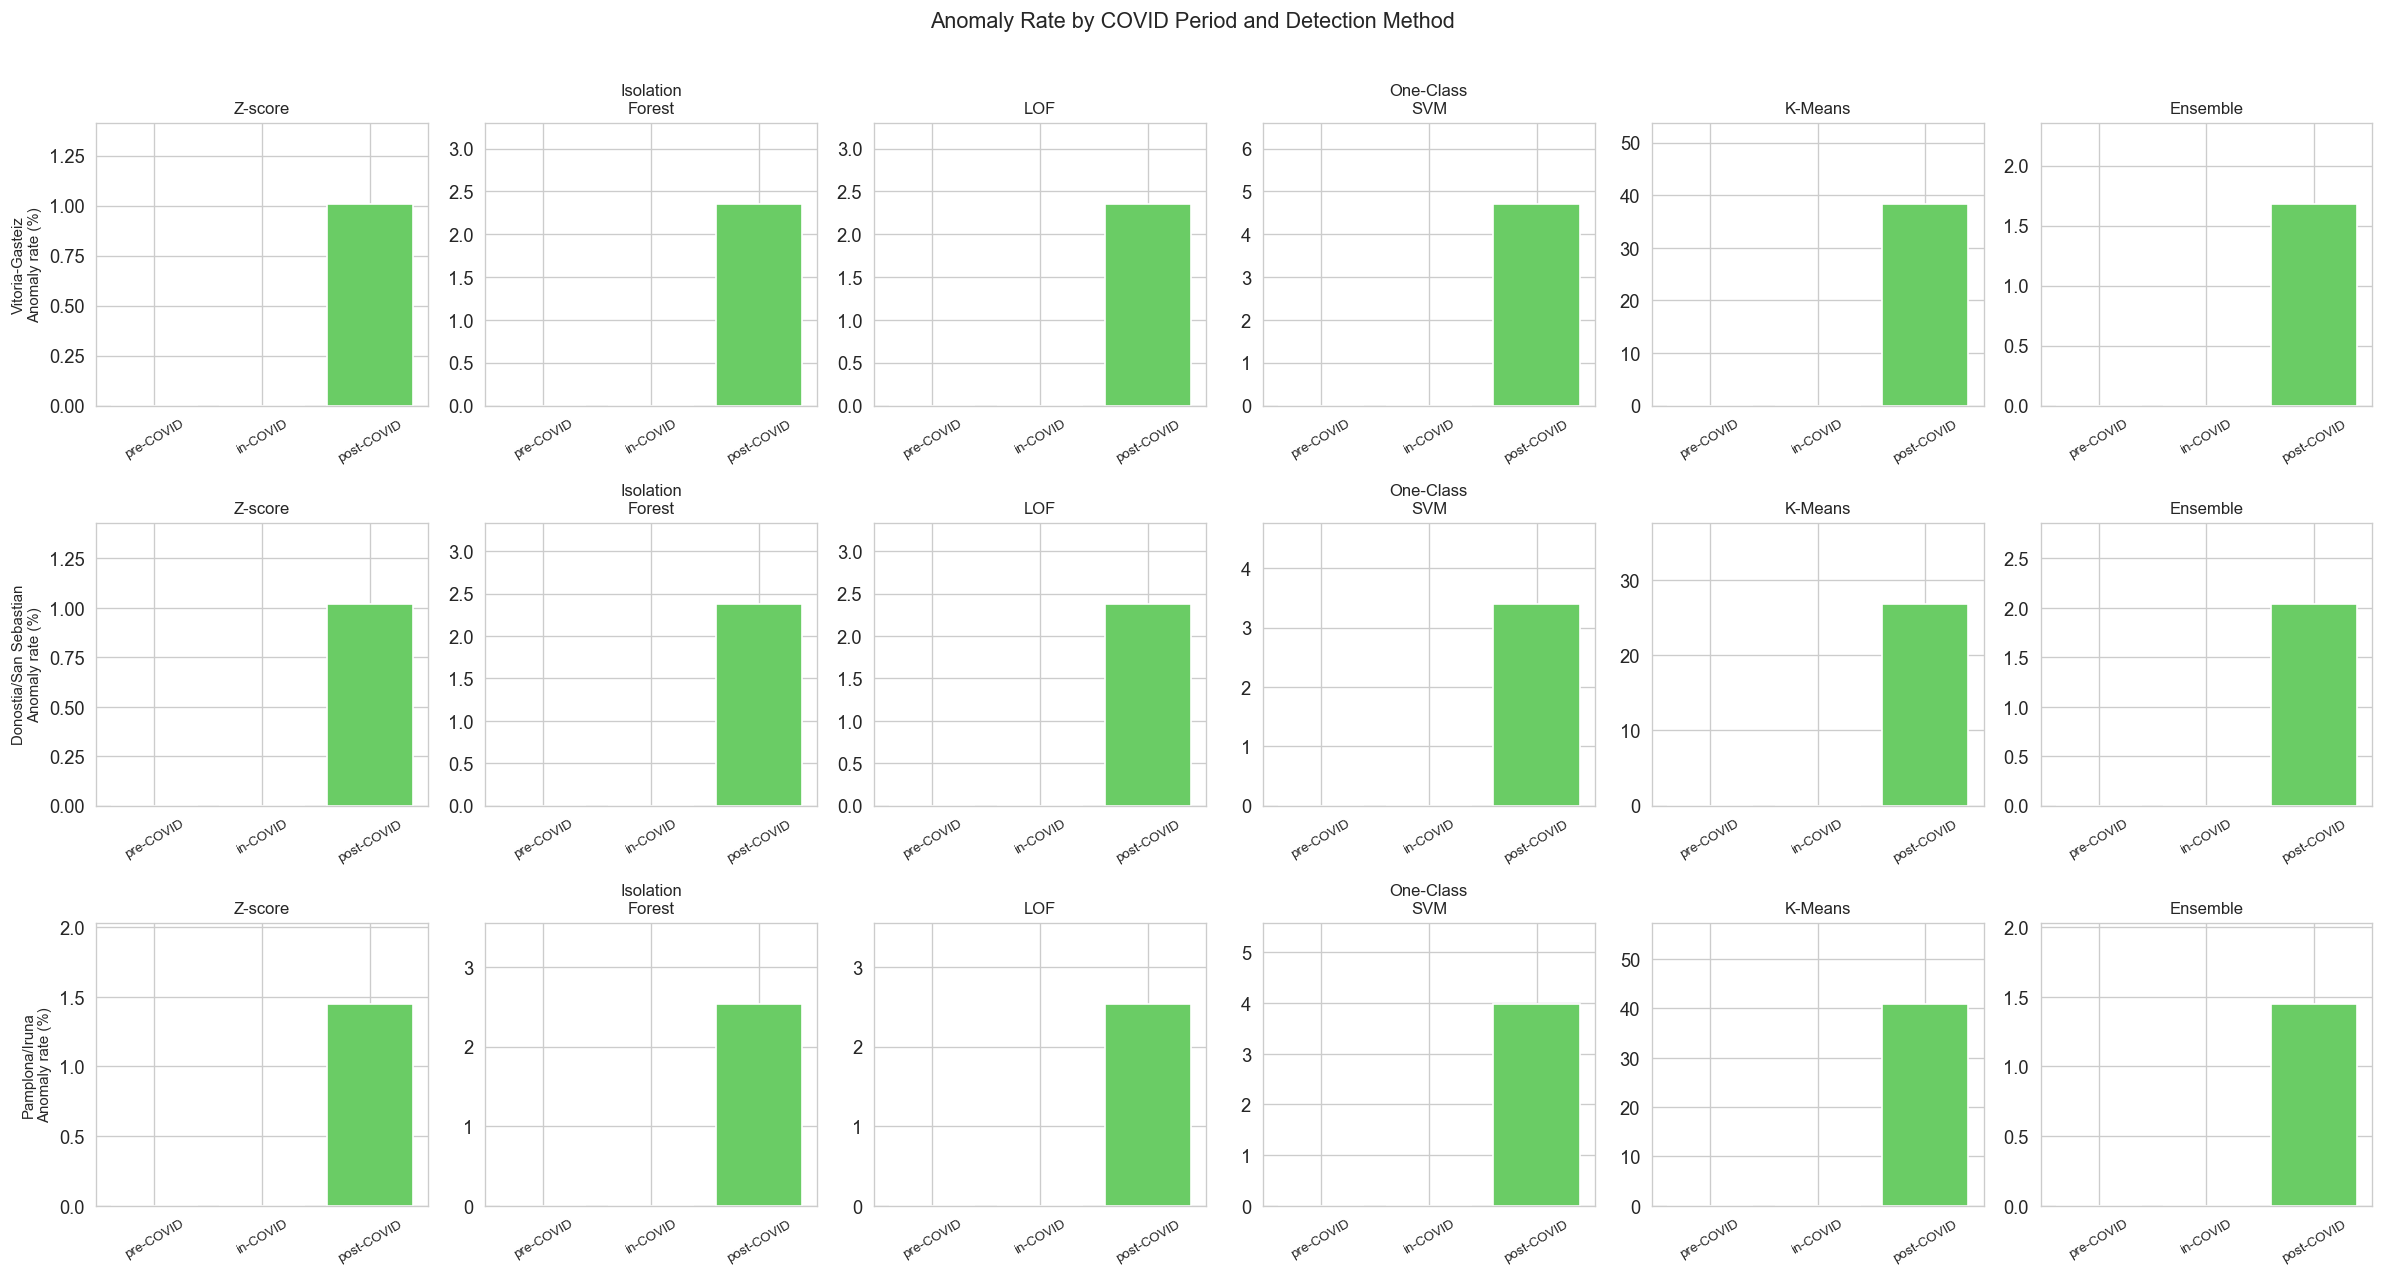

Saved temporal_distribution.png


In [4]:
flag_cols = ['zscore_flag','iforest_flag','lof_flag','ocsvm_flag','kmeans_flag','ensemble_flag']
method_labels = ['Z-score', 'Isolation\nForest', 'LOF', 'One-Class\nSVM', 'K-Means', 'Ensemble']

period_order = ['pre-COVID', 'in-COVID', 'post-COVID']
period_palette = {'pre-COVID': '#4878CF', 'in-COVID': '#D65F5F', 'post-COVID': '#6ACC65'}

fig, axes = plt.subplots(len(MUNICIPALITIES), len(flag_cols),
                          figsize=(20, 3.5 * len(MUNICIPALITIES)), sharey=False)

for row_idx, (city, df) in enumerate(results.items()):
    for col_idx, (col, label) in enumerate(zip(flag_cols, method_labels)):
        ax = axes[row_idx, col_idx]
        period_counts = (
            df[df[col] == 1]
            .groupby('period')[col]
            .count()
            .reindex(period_order, fill_value=0)
        )
        period_totals = df.groupby('period')[col].count().reindex(period_order, fill_value=1)
        period_rates  = 100 * period_counts / period_totals

        bars = ax.bar(period_order, period_rates,
                      color=[period_palette[p] for p in period_order], edgecolor='white')
        ax.set_ylim(0, max(period_rates.max() * 1.4, 1))
        ax.set_ylabel('Anomaly rate (%)' if col_idx == 0 else '')
        ax.set_title(label, fontsize=10)
        if row_idx == 0:
            pass  # title already set
        if col_idx == 0:
            ax.set_ylabel(f"{city}\nAnomaly rate (%)", fontsize=9)
        ax.tick_params(axis='x', labelrotation=30, labelsize=8)

fig.suptitle('Anomaly Rate by COVID Period and Detection Method', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(OUT_DIR / 'temporal_distribution.png', bbox_inches='tight')
plt.show()
print('Saved temporal_distribution.png')

## 4. Residual Time-Series with Anomaly Flags

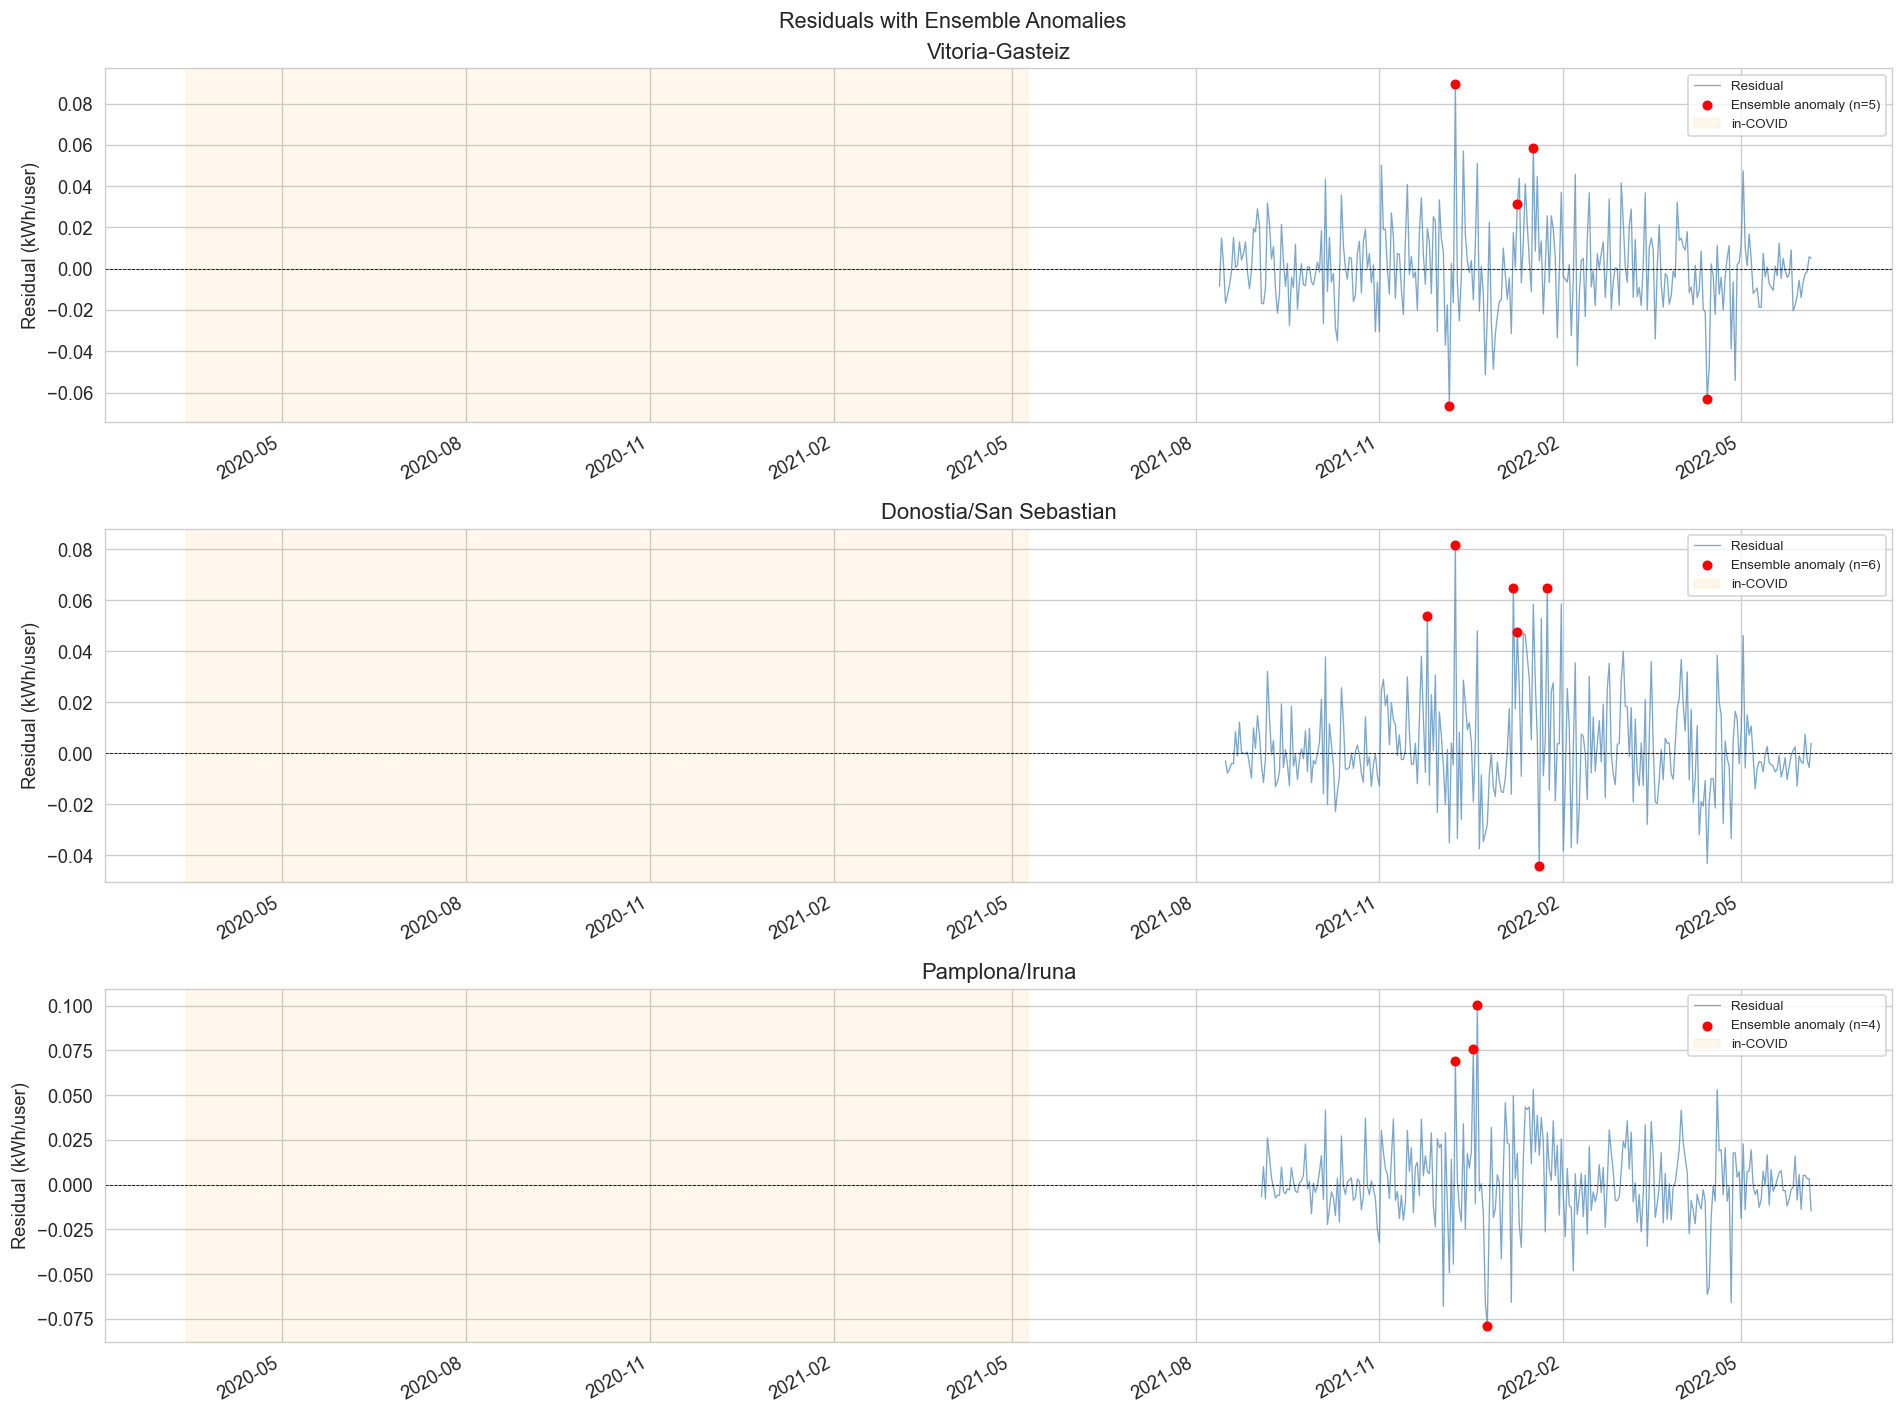

Saved residuals_with_anomalies.png


In [5]:
fig, axes = plt.subplots(len(MUNICIPALITIES), 1,
                          figsize=(16, 4 * len(MUNICIPALITIES)), sharex=False)

for ax, (city, df) in zip(axes, results.items()):
    ax.plot(df['date'], df['residual'], color='steelblue', lw=0.8, alpha=0.7, label='Residual')

    ensemble_anom = df[df['ensemble_flag'] == 1]
    ax.scatter(ensemble_anom['date'], ensemble_anom['residual'],
               color='red', s=25, zorder=5, label=f"Ensemble anomaly (n={len(ensemble_anom)})")

    # COVID shading
    ymin, ymax = ax.get_ylim()
    ax.axvspan(COVID_START, COVID_END, alpha=0.08, color='orange', label='in-COVID')

    ax.axhline(0, color='k', lw=0.5, ls='--')
    ax.set_title(city)
    ax.set_ylabel('Residual (kWh/user)')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')
    ax.legend(fontsize=8, loc='upper right')

plt.suptitle('Residuals with Ensemble Anomalies', fontsize=13)
plt.tight_layout()
plt.savefig(OUT_DIR / 'residuals_with_anomalies.png', bbox_inches='tight')
plt.show()
print('Saved residuals_with_anomalies.png')

## 5. Cross-Method Agreement

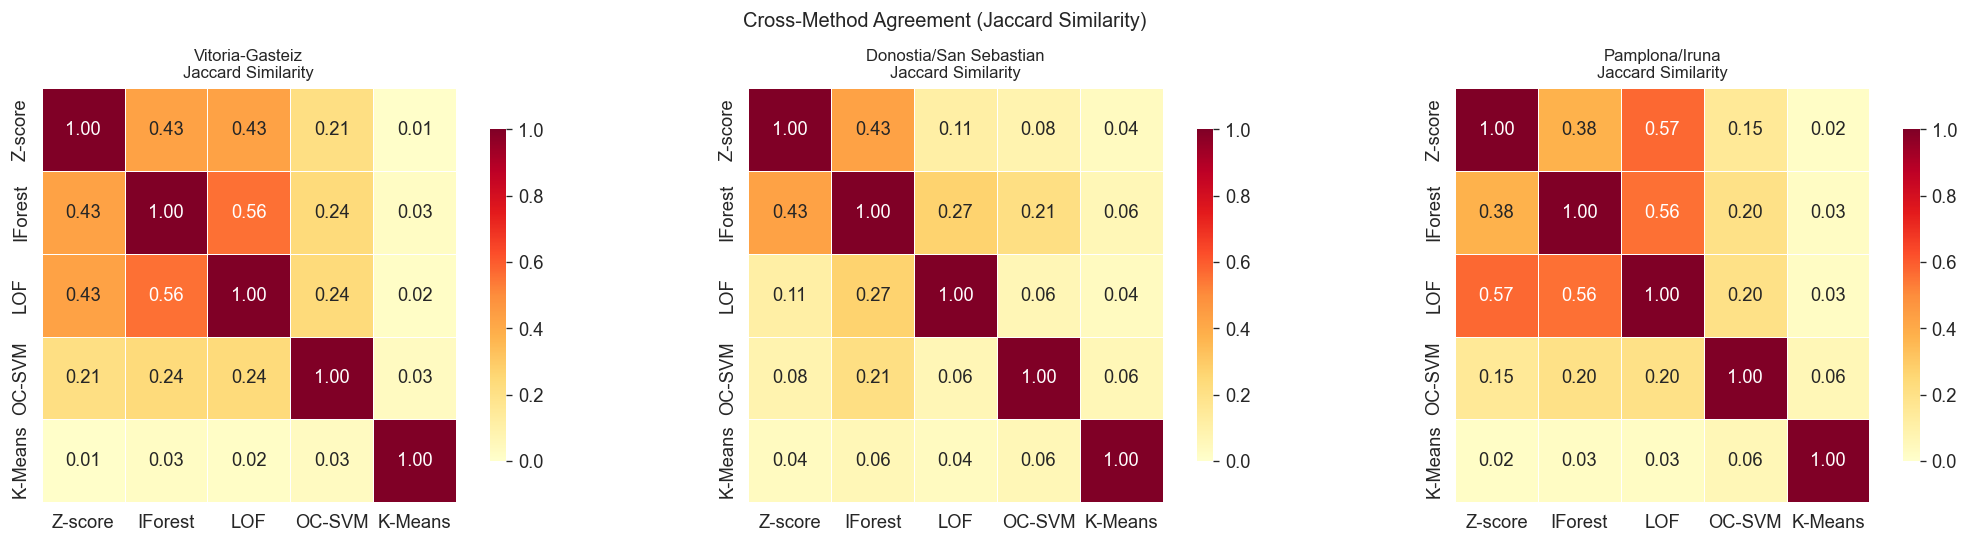

Saved cross_method_agreement.png


In [6]:
from sklearn.metrics import jaccard_score

method_names = ['Z-score', 'IForest', 'LOF', 'OC-SVM', 'K-Means']
flag_cols5   = ['zscore_flag','iforest_flag','lof_flag','ocsvm_flag','kmeans_flag']

fig, axes = plt.subplots(1, len(MUNICIPALITIES), figsize=(6 * len(MUNICIPALITIES), 4.5))

for ax, (city, df) in zip(axes, results.items()):
    n_methods = len(flag_cols5)
    jac = np.zeros((n_methods, n_methods))
    for i, c1 in enumerate(flag_cols5):
        for j, c2 in enumerate(flag_cols5):
            if df[c1].sum() == 0 and df[c2].sum() == 0:
                jac[i, j] = 1.0
            else:
                jac[i, j] = jaccard_score(df[c1], df[c2], zero_division=0)

    jac_df = pd.DataFrame(jac, index=method_names, columns=method_names)
    sns.heatmap(jac_df, annot=True, fmt='.2f', cmap='YlOrRd',
                vmin=0, vmax=1, ax=ax, square=True,
                linewidths=0.5, cbar_kws={'shrink': 0.8})
    ax.set_title(f'{city}\nJaccard Similarity', fontsize=10)

plt.suptitle('Cross-Method Agreement (Jaccard Similarity)', fontsize=12)
plt.tight_layout()
plt.savefig(OUT_DIR / 'cross_method_agreement.png', bbox_inches='tight')
plt.show()
print('Saved cross_method_agreement.png')

## 6. Summary Table — Anomaly Rates per City, Method, and Period

In [7]:
rows = []
period_order = ['pre-COVID', 'in-COVID', 'post-COVID', 'ALL']

for city, df in results.items():
    for col, name in zip(flag_cols, ['Z-score','IForest','LOF','OC-SVM','K-Means','Ensemble']):
        for period in ['pre-COVID', 'in-COVID', 'post-COVID']:
            sub = df[df['period'] == period]
            rate = 100 * sub[col].mean() if len(sub) > 0 else np.nan
            rows.append({'city': city, 'method': name, 'period': period, 'anomaly_rate_%': round(rate, 2) if not np.isnan(rate) else np.nan})
        rate_all = 100 * df[col].mean()
        rows.append({'city': city, 'method': name, 'period': 'ALL', 'anomaly_rate_%': round(rate_all, 2)})

summary_df = pd.DataFrame(rows)
pivot = (
    summary_df
    .pivot_table(index=['city','method'], columns='period', values='anomaly_rate_%', aggfunc='mean')
    .reindex(columns=period_order)
)
print(pivot.to_string())

summary_df.to_csv(OUT_DIR / 'anomaly_rates_summary.csv', index=False)
pivot.to_csv(OUT_DIR / 'anomaly_rates_pivot.csv')
print('\nSaved anomaly_rates_summary.csv and anomaly_rates_pivot.csv')

period                           pre-COVID  in-COVID  post-COVID    ALL
city                   method                                          
Donostia/San Sebastian Ensemble        NaN       NaN        2.04   2.04
                       IForest         NaN       NaN        2.38   2.38
                       K-Means         NaN       NaN       26.87  26.87
                       LOF             NaN       NaN        2.38   2.38
                       OC-SVM          NaN       NaN        3.40   3.40
                       Z-score         NaN       NaN        1.02   1.02
Pamplona/Iruna         Ensemble        NaN       NaN        1.45   1.45
                       IForest         NaN       NaN        2.54   2.54
                       K-Means         NaN       NaN       40.94  40.94
                       LOF             NaN       NaN        2.54   2.54
                       OC-SVM          NaN       NaN        3.99   3.99
                       Z-score         NaN       NaN        1.45

## 7. Inspect Top Anomalous Days (Ensemble)

In [8]:
for city, df in results.items():
    anom = (
        df[df['ensemble_flag'] == 1]
        .sort_values('z_residual', key=lambda s: s.abs(), ascending=False)
        [['date', 'actual', BEST_MODEL, 'residual', 'z_residual', 'period', 'ensemble_votes']]
        .head(15)
    )
    print(f"\n{'='*60}")
    print(f"  {city} — top ensemble anomalies")
    print(f"{'='*60}")
    print(anom.to_string(index=False))


  Vitoria-Gasteiz — top ensemble anomalies
      date   actual  N-BEATS v2 (covariate-conditioned)  residual  z_residual     period  ensemble_votes
2021-12-09 0.411623                            0.322379  0.089245    4.402139 post-COVID               5
2021-12-06 0.270391                            0.336727 -0.066336   -3.282956 post-COVID               4
2022-04-14 0.213779                            0.277078 -0.063299   -3.132916 post-COVID               4
2022-01-17 0.399237                            0.340619  0.058617    2.889260 post-COVID               3
2022-01-09 0.297596                            0.266168  0.031428    1.546204 post-COVID               3

  Donostia/San Sebastian — top ensemble anomalies
      date   actual  N-BEATS v2 (covariate-conditioned)  residual  z_residual     period  ensemble_votes
2021-12-09 0.509665                            0.427850  0.081815    4.110873 post-COVID               4
2022-01-07 0.434247                            0.369513  0.064733

## 8. Residual Distribution — Anomalies vs Normal Days

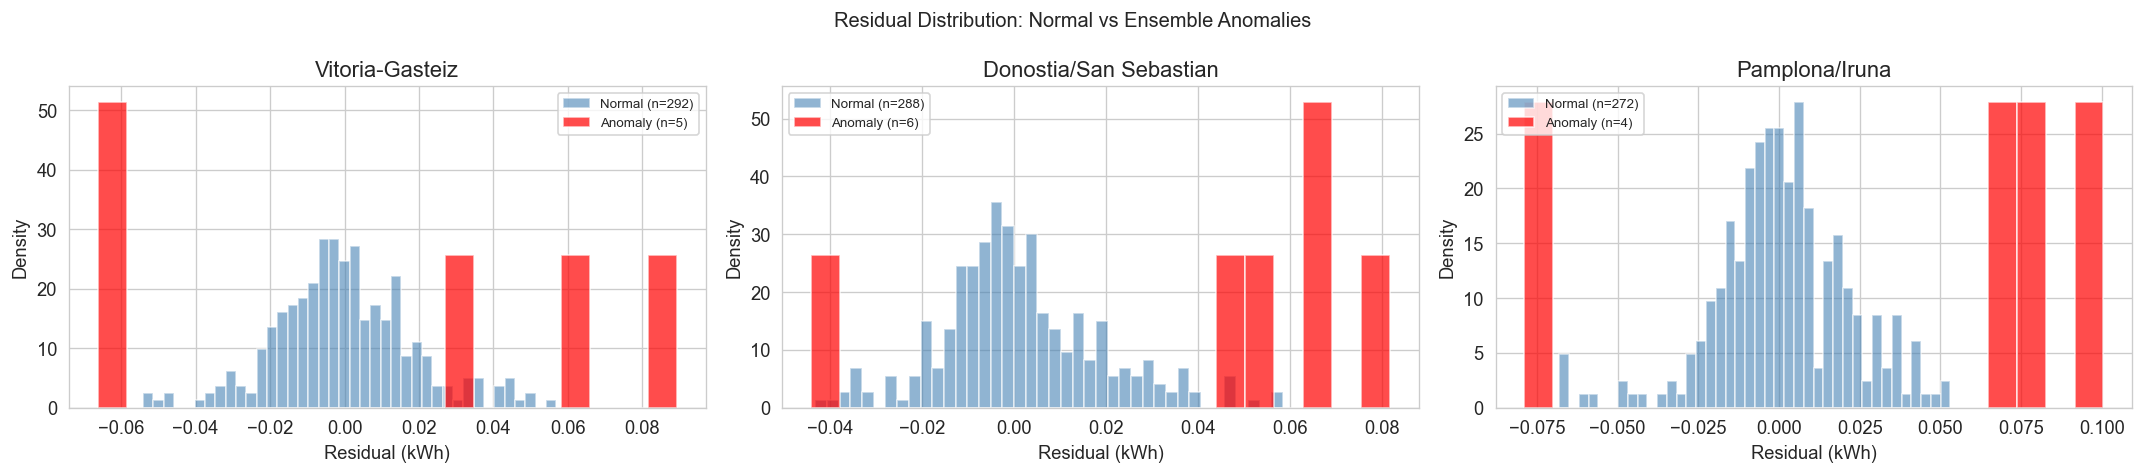

Saved residual_distribution.png


In [9]:
fig, axes = plt.subplots(1, len(MUNICIPALITIES), figsize=(6 * len(MUNICIPALITIES), 4))

for ax, (city, df) in zip(axes, results.items()):
    normal = df[df['ensemble_flag'] == 0]['residual']
    anom   = df[df['ensemble_flag'] == 1]['residual']

    ax.hist(normal, bins=40, alpha=0.6, color='steelblue', label=f'Normal (n={len(normal)})', density=True)
    ax.hist(anom,   bins=20, alpha=0.7, color='red',       label=f'Anomaly (n={len(anom)})',  density=True)
    ax.set_xlabel('Residual (kWh)')
    ax.set_ylabel('Density')
    ax.set_title(city)
    ax.legend(fontsize=8)

plt.suptitle('Residual Distribution: Normal vs Ensemble Anomalies', fontsize=12)
plt.tight_layout()
plt.savefig(OUT_DIR / 'residual_distribution.png', bbox_inches='tight')
plt.show()
print('Saved residual_distribution.png')

## 9. Save Full Anomaly Tables

In [10]:
for city, df in results.items():
    safe = city.replace('/', '_').replace(' ', '_')
    path = OUT_DIR / f'{safe}_anomaly_flags.csv'
    df.to_csv(path, index=False)
    print(f'Saved {path.name}')

print('\nAll results saved to:', OUT_DIR)

Saved Vitoria-Gasteiz_anomaly_flags.csv
Saved Donostia_San_Sebastian_anomaly_flags.csv
Saved Pamplona_Iruna_anomaly_flags.csv

All results saved to: c:\Users\GONCA\Desktop\Iscte\MCD\Theses\anomaly_detection_results
